In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass

In [2]:
@dataclass
class Measurement:
    width: int
    depth: int
    loss: np.ndarray
    trace: np.ndarray
    entropy: np.ndarray
    class_entropy: dict

In [3]:
single_out = np.load("single-output/long-time-analysis.npy", allow_pickle=True)
double_out = np.load("double-output/long-time-analysis.npy", allow_pickle=True)
double_out_ce = np.load("double-output-ce/long-time-analysis.npy", allow_pickle=True)

In [4]:
x = np.linspace(1, 10000, 500)

## Width Scaling

In [5]:
depth = 2

In [6]:
single = [item for item in single_out if item.depth == depth]
double = [item for item in double_out if item.depth == depth]
double_ce = [item for item in double_out_ce if item.depth == depth]

## Loss Evolution

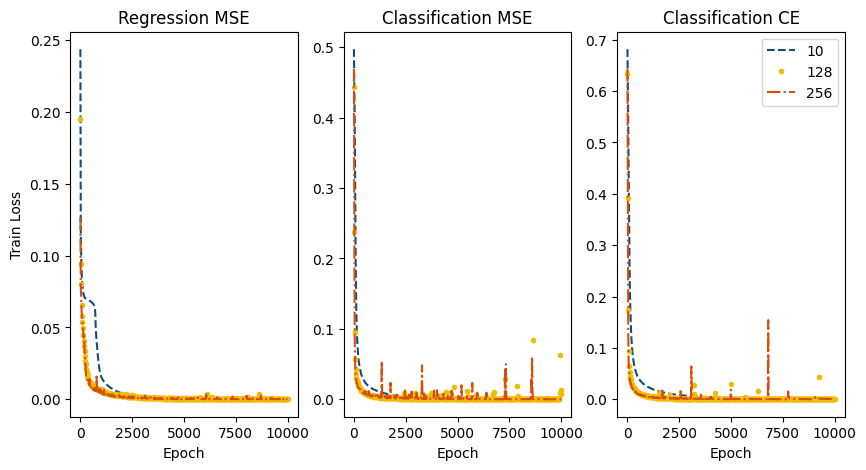

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

styles = ["--", ".", "-."]
colours = ["#124E78", "#F2BB05", "#D74E09"]

for i, item in enumerate(single):
    ax[0].plot(x, item.loss, styles[i], label=item.width, c=colours[i])
    ax[0].set_title("Regression MSE")
    
for i, item in enumerate(double):
    ax[1].plot(x, item.loss, styles[i], label=item.width, c=colours[i])
    ax[1].set_title("Classification MSE")
    
for i, item in enumerate(double_ce):
    ax[2].plot(x, item.loss, styles[i], label=item.width, c=colours[i])
    ax[2].set_title("Classification CE")
    
ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")

ax[0].set_ylabel("Train Loss")


plt.legend()
plt.savefig("loss-long-time-width-scaling.png", dpi=400)
plt.show()

## Entropy vs Layers

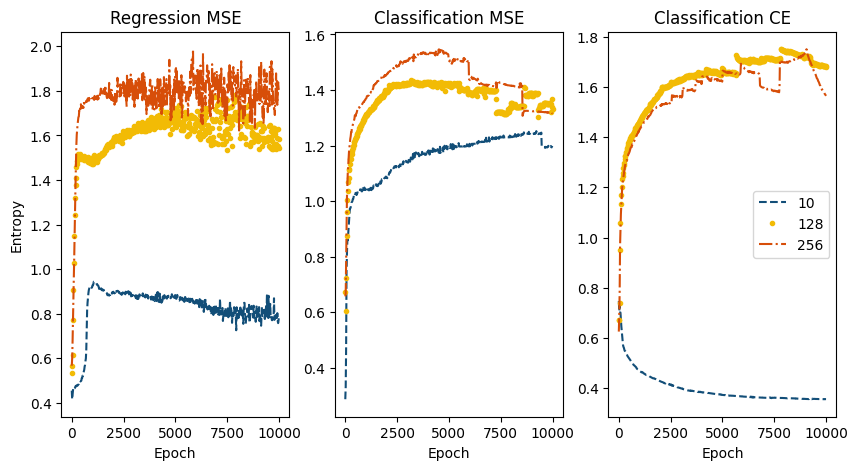

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

styles = ["--", ".", "-."]
colours = ["#124E78", "#F2BB05", "#D74E09"]

for i, item in enumerate(single):
    ax[0].plot(x, item.entropy, styles[i], label=item.width, c=colours[i])
    ax[0].set_title("Regression MSE")
    
for i, item in enumerate(double):
    ax[1].plot(x, item.entropy, styles[i], label=item.width, c=colours[i])
    ax[1].set_title("Classification MSE")
    
for i, item in enumerate(double_ce):
    ax[2].plot(x, item.entropy, styles[i], label=item.width, c=colours[i])
    ax[2].set_title("Classification CE")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[0].set_ylabel("Entropy")

plt.legend()
plt.savefig("entropy-long-time-width-scaling.png", dpi=400)
plt.show()

## Trace vs Layers

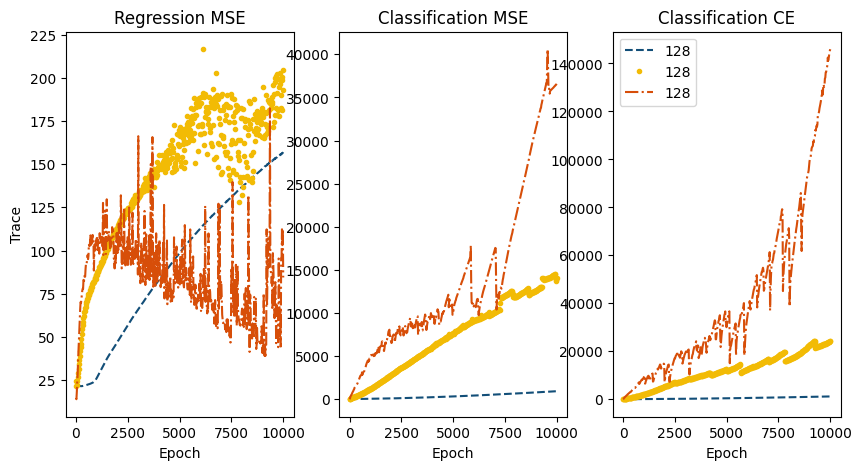

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

styles = ["--", ".", "-."]
colours = ["#124E78", "#F2BB05", "#D74E09"]

for i, item in enumerate(single):
    ax[0].plot(x, item.trace / 500, styles[i], label=item.width, c=colours[i])
    ax[0].set_title("Regression MSE")
    
for i, item in enumerate(double):
    ax[1].plot(x, item.trace / 500, styles[i], label=item.width, c=colours[i])
    ax[1].set_title("Classification MSE")
    
for i, item in enumerate(double_ce):
    ax[2].plot(x, item.trace / 500, styles[i], label=item.width, c=colours[i])
    ax[2].set_title("Classification CE")

    
ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[0].set_ylabel("Trace")

plt.legend()
# ax[0].set_yscale("log")
# plt.savefig("trace-long-time-width-scaling.png", dpi=400)
plt.show()

## Class Entropy

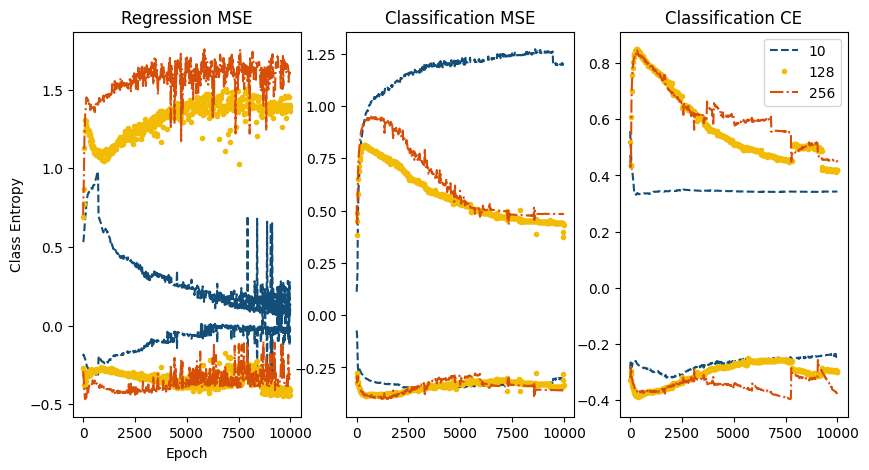

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

styles = ["--", ".", "-."]
colours = ["#124E78", "#F2BB05", "#D74E09"]

for i, item in enumerate(single):
    
    class_one = [subitem["one"] for subitem in item.class_entropy]
    class_two = [subitem["two"] for subitem in item.class_entropy]
    class_cross = [subitem["cross"] for subitem in item.class_entropy]

    ax[0].plot(x, class_one, styles[i], label=item.width, c=colours[i])
#     ax[0].plot(x, class_two, styles[i], label=item.width, c=colours[i])
    ax[0].plot(x, class_cross, styles[i], c=colours[i])

    ax[0].set_title("Regression MSE")
    
for i, item in enumerate(double):
    class_one = [subitem["one"] for subitem in item.class_entropy]
    class_two = [subitem["two"] for subitem in item.class_entropy]
    class_cross = [subitem["cross"] for subitem in item.class_entropy]

    ax[1].plot(x, class_one, styles[i], label=item.width, c=colours[i])
#     ax[1].plot(x, class_two, styles[i], label=item.width, c=colours[i])
    ax[1].plot(x, class_cross, styles[i], c=colours[i])
    ax[1].set_title("Classification MSE")
    
for i, item in enumerate(double_ce):
    class_one = [subitem["one"] for subitem in item.class_entropy]
    class_two = [subitem["two"] for subitem in item.class_entropy]
    class_cross = [subitem["cross"] for subitem in item.class_entropy]

    ax[2].plot(x, class_one, styles[i], label=item.width, c=colours[i])
#     ax[2].plot(x, class_two, styles[i], label=item.width, c=colours[i])
    ax[2].plot(x, class_cross, styles[i] , c=colours[i])
    ax[2].set_title("Classification CE")


ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Class Entropy")

plt.legend()
plt.savefig("class-entropy-long-time-width-scaling.png", dpi=400)
plt.show()

## Depth Scaling

In [11]:
width = 128

In [12]:
single = [item for item in single_out if item.width == width]
double = [item for item in double_out if item.width == width]
double_ce = [item for item in double_out_ce if item.width == width]

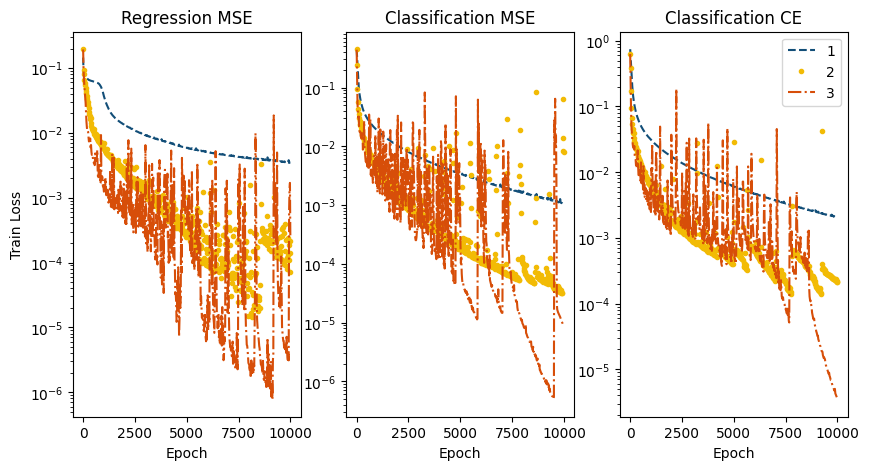

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

styles = ["--", ".", "-."]
colours = ["#124E78", "#F2BB05", "#D74E09"]

for i, item in enumerate(single):
    ax[0].plot(x, item.loss, styles[i], label=item.depth, c=colours[i])
    ax[0].set_title("Regression MSE")
    
for i, item in enumerate(double):
    ax[1].plot(x, item.loss, styles[i], label=item.depth, c=colours[i])
    ax[1].set_title("Classification MSE")
    
for i, item in enumerate(double_ce):
    ax[2].plot(x, item.loss, styles[i], label=item.depth, c=colours[i])
    ax[2].set_title("Classification CE")
    
ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")

ax[0].set_ylabel("Train Loss")

ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[2].set_yscale("log")


plt.legend()
plt.savefig("loss-long-time-depth-scaling.png", dpi=400)
plt.show()

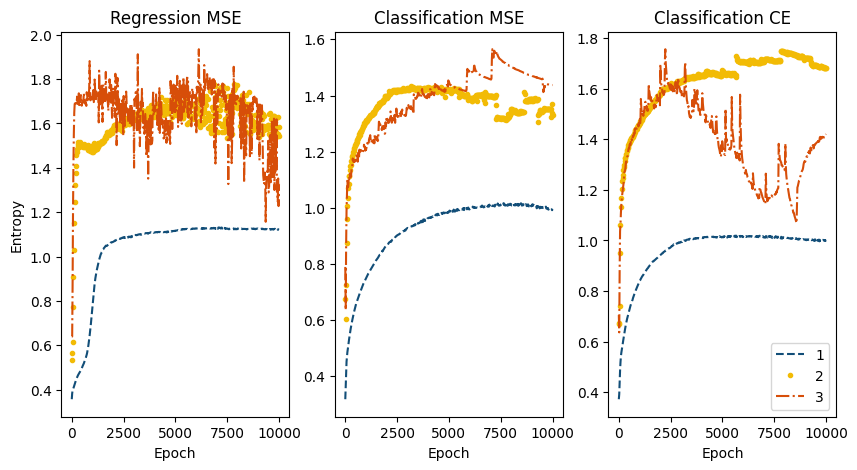

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

styles = ["--", ".", "-."]
colours = ["#124E78", "#F2BB05", "#D74E09"]

for i, item in enumerate(single):
    ax[0].plot(x, item.entropy, styles[i], label=item.depth, c=colours[i])
    ax[0].set_title("Regression MSE")
    
for i, item in enumerate(double):
    ax[1].plot(x, item.entropy, styles[i], label=item.depth, c=colours[i])
    ax[1].set_title("Classification MSE")
    
for i, item in enumerate(double_ce):
    ax[2].plot(x, item.entropy, styles[i], label=item.depth, c=colours[i])
    ax[2].set_title("Classification CE")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[0].set_ylabel("Entropy")

plt.legend()
plt.savefig("entropy-long-time-depth-scaling.png", dpi=400)
plt.show()

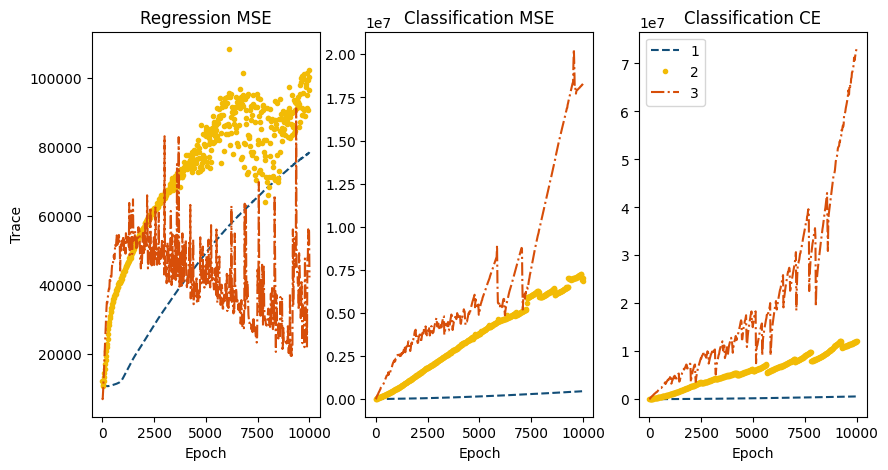

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

styles = ["--", ".", "-."]
colours = ["#124E78", "#F2BB05", "#D74E09"]

for i, item in enumerate(single):
    ax[0].plot(x, item.trace, styles[i], label=item.depth, c=colours[i])
    ax[0].set_title("Regression MSE")
    
for i, item in enumerate(double):
    ax[1].plot(x, item.trace, styles[i], label=item.depth, c=colours[i])
    ax[1].set_title("Classification MSE")
    
for i, item in enumerate(double_ce):
    ax[2].plot(x, item.trace, styles[i], label=item.depth, c=colours[i])
    ax[2].set_title("Classification CE")

    
ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[0].set_ylabel("Trace")

plt.legend()
# ax[0].set_yscale("log")
plt.savefig("trace-long-time-depth-scaling.png", dpi=400)
plt.show()

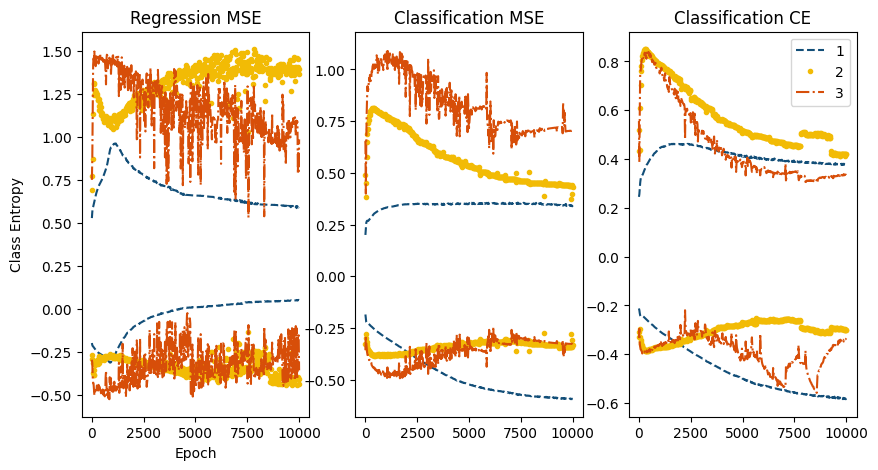

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

styles = ["--", ".", "-."]
colours = ["#124E78", "#F2BB05", "#D74E09"]

for i, item in enumerate(single):
    
    class_one = [subitem["one"] for subitem in item.class_entropy]
    class_two = [subitem["two"] for subitem in item.class_entropy]
    class_cross = [subitem["cross"] for subitem in item.class_entropy]

    ax[0].plot(x, class_one, styles[i], label=item.depth, c=colours[i])
#     ax[0].plot(x, class_two, styles[i], label=item.depth, c=colours[i])
    ax[0].plot(x, class_cross, styles[i], c=colours[i])
    ax[0].set_title("Regression MSE")
    
for i, item in enumerate(double):
    class_one = [subitem["one"] for subitem in item.class_entropy]
    class_two = [subitem["two"] for subitem in item.class_entropy]
    class_cross = [subitem["cross"] for subitem in item.class_entropy]

    ax[1].plot(x, class_one, styles[i], label=item.depth, c=colours[i])
#     ax[1].plot(x, class_two, styles[i], label=item.width, c=colours[i])
    ax[1].plot(x, class_cross, styles[i], c=colours[i])
    ax[1].set_title("Classification MSE")
    
for i, item in enumerate(double_ce):
    class_one = [subitem["one"] for subitem in item.class_entropy]
    class_two = [subitem["two"] for subitem in item.class_entropy]
    class_cross = [subitem["cross"] for subitem in item.class_entropy]

    ax[2].plot(x, class_one, styles[i], label=item.depth, c=colours[i])
#     ax[2].plot(x, class_two, styles[i], label=item.width, c=colours[i])
    ax[2].plot(x, class_cross, styles[i] , c=colours[i])
    ax[2].set_title("Classification CE")


ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Class Entropy")

plt.legend()
plt.savefig("class-entropy-long-time-depth-scaling.png", dpi=400)
plt.show()